# Etapa 4 - Avaliacao e Golden Set

Avaliar conversao, recompensa acumulada e cinco casos representativos de recomendacao.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mabwiser.mab import MAB, LearningPolicy
from sklearn.model_selection import train_test_split

PROCESSED_DIR = Path('../data/processed/bank-term-deposit-subscription_eda')
DATA_PATH = PROCESSED_DIR / 'bank_full_tratado.csv'
RESULTS_PATH = PROCESSED_DIR / 'bandit_results.csv'
METRICS_PATH = PROCESSED_DIR / 'bandit_metrics.json'
STATE_PATH = PROCESSED_DIR / 'thompson_sampling_state.json'

if not DATA_PATH.exists():
    raise FileNotFoundError('Execute primeiro o Notebook 2 para gerar a base tratada.')

if not RESULTS_PATH.exists() or not METRICS_PATH.exists():
    raise FileNotFoundError('Execute primeiro o Notebook 3 para gerar os artefatos de avaliação.')

data = pd.read_csv(DATA_PATH)
if 'duration' in data.columns:
    raise ValueError('Leakage detectado no Golden Set: duration')
if set(data['contact'].unique()) - {'cellular', 'telephone'}:
    raise ValueError('A base contém braços não acionáveis.')
if not {'contact', 'y'}.issubset(data.columns):
    raise ValueError('A base precisa conter as colunas contact e y.')

with METRICS_PATH.open(encoding='utf-8') as file:
    metrics = json.load(file)

with STATE_PATH.open(encoding='utf-8') as file:
    model_state = json.load(file)

results = pd.read_csv(RESULTS_PATH)
print(f'Base validada: {len(data)} exemplos, sem duration.')
print(f'Política avaliada: {model_state.get("policy", metrics.get("policy", "desconhecida"))}')

Base validada: 32191 exemplos, sem duration.
Política avaliada: MABWiser ThompsonSampling


Taxas de conversão no treino:


,contact,observations,conversions,conversion_rate
0,cellular,20476,3064,0.149639
1,telephone,2057,267,0.129801


Métricas da avaliação:


,metric,value
0,Conversão baseline,10.44%
1,Conversão Thompson Sampling,13.67%
2,Ganho absoluto,3.23%
3,Ganho relativo,30.95%
4,Recompensa acumulada baseline,100800.00%
5,Recompensa acumulada Thompson,132000.00%


Recompensa acumulada baseline: 1008
Recompensa acumulada Thompson: 1320


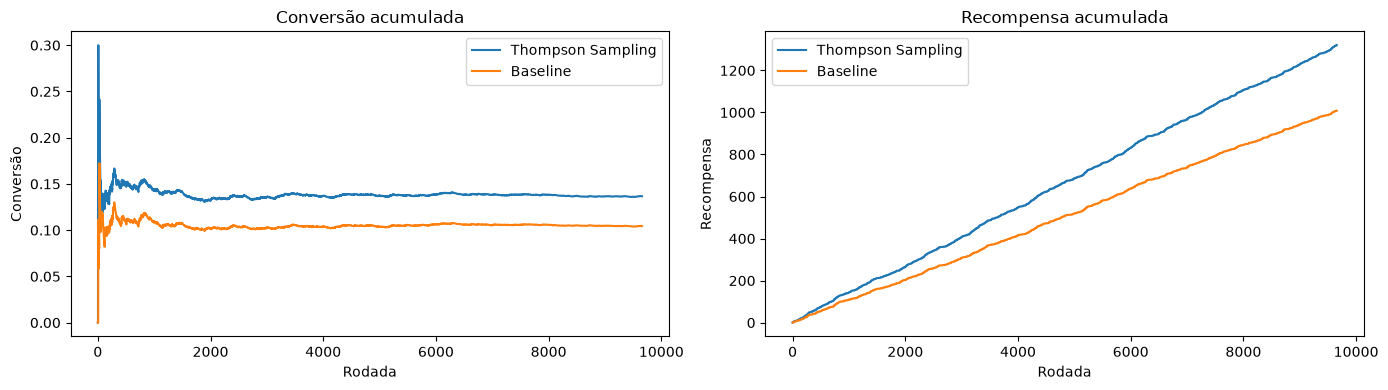

Golden Set: recomendações para cinco clientes


,case,source_index,recommended_arm,recommended_rate,alternative_arm,alternative_rate,observed_outcome,decision_makes_sense,reason
0,1,24502,cellular,0.149639,telephone,0.129801,0,True,"cellular possui taxa histórica de 14.96%, maio..."
1,2,31140,cellular,0.149639,telephone,0.129801,1,True,"cellular possui taxa histórica de 14.96%, maio..."
2,3,9946,cellular,0.149639,telephone,0.129801,0,True,"cellular possui taxa histórica de 14.96%, maio..."
3,4,3807,cellular,0.149639,telephone,0.129801,0,True,"cellular possui taxa histórica de 14.96%, maio..."
4,5,20545,cellular,0.149639,telephone,0.129801,0,True,"cellular possui taxa histórica de 14.96%, maio..."


Golden Set salvo em: ..\data\processed\bank-term-deposit-subscription_eda\golden_set_recommendations.csv


In [2]:
train_df, test_df = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    stratify=data['y']
)

arm_stats = (
    train_df.groupby('contact', as_index=False)
    .agg(
        observations=('y', 'size'),
        conversions=('y', 'sum'),
        conversion_rate=('y', 'mean')
    )
    .sort_values('conversion_rate', ascending=False)
)
arms = arm_stats['contact'].tolist()
real_rates = dict(zip(arm_stats['contact'], arm_stats['conversion_rate']))
fixed_arm = metrics.get('baseline_arm', 'telephone')

print('Taxas de conversão no treino:')
display(arm_stats)
results = results.copy()
results['thompson_reward'] = results['thompson_reward'].astype(int)
results['baseline_reward'] = results['baseline_reward'].astype(int)

baseline_conversion = results['baseline_reward'].mean()
thompson_conversion = results['thompson_reward'].mean()
conversion_lift = thompson_conversion - baseline_conversion

summary_metrics = pd.DataFrame([
    {'metric': 'Conversão baseline', 'value': baseline_conversion},
    {'metric': 'Conversão Thompson Sampling', 'value': thompson_conversion},
    {'metric': 'Ganho absoluto', 'value': conversion_lift},
    {'metric': 'Ganho relativo', 'value': conversion_lift / baseline_conversion if baseline_conversion else np.nan},
    {'metric': 'Recompensa acumulada baseline', 'value': results['baseline_reward'].sum()},
    {'metric': 'Recompensa acumulada Thompson', 'value': results['thompson_reward'].sum()},
])

print('Métricas da avaliação:')
display(summary_metrics.style.format({'value': '{:.2%}'}))
print(f"Recompensa acumulada baseline: {results['baseline_reward'].sum()}")
print(f"Recompensa acumulada Thompson: {results['thompson_reward'].sum()}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

results[['thompson_cumulative_conversion', 'baseline_cumulative_conversion']].plot(ax=axes[0])
axes[0].set_title('Conversão acumulada')
axes[0].set_xlabel('Rodada')
axes[0].set_ylabel('Conversão')
axes[0].legend(['Thompson Sampling', 'Baseline'])

results[['thompson_reward', 'baseline_reward']].cumsum().plot(ax=axes[1])
axes[1].set_title('Recompensa acumulada')
axes[1].set_xlabel('Rodada')
axes[1].set_ylabel('Recompensa')
axes[1].legend(['Thompson Sampling', 'Baseline'])

plt.tight_layout()
plt.show()
golden_set = test_df.head(5).copy()

# O notebook 3 usa Thompson Sampling não contextual: a entrada da decisão é o histórico,
# e predict() retorna apenas o braço escolhido.
mab = MAB(
    arms=arms,
    learning_policy=LearningPolicy.ThompsonSampling()
)
mab.fit(
    decisions=train_df['contact'].to_numpy(),
    rewards=train_df['y'].to_numpy(),
)

recommendations = []
for case_number, (index, row) in enumerate(golden_set.iterrows(), start=1):
    recommended_arm = mab.predict()
    recommended_rate = float(real_rates[recommended_arm])
    alternative_arm = next(arm for arm in arms if arm != recommended_arm)
    alternative_rate = float(real_rates[alternative_arm])
    recommendations.append({
        'case': case_number,
        'source_index': int(index),
        'recommended_arm': recommended_arm,
        'recommended_rate': recommended_rate,
        'alternative_arm': alternative_arm,
        'alternative_rate': alternative_rate,
        'observed_outcome': int(row['y']),
        'decision_makes_sense': recommended_rate >= alternative_rate,
        'reason': (
            f"{recommended_arm} possui taxa histórica de {recommended_rate:.2%}, "
            f"maior ou igual à alternativa {alternative_arm} ({alternative_rate:.2%})."
        ),
    })

recommendations = pd.DataFrame(recommendations)
print('Golden Set: recomendações para cinco clientes')
display(recommendations)
golden_set_path = PROCESSED_DIR / 'golden_set_recommendations.csv'
recommendations.to_csv(golden_set_path, index=False)

if len(recommendations) != 5:
    raise AssertionError('O Golden Set precisa conter exatamente cinco casos.')
if recommendations['recommended_arm'].isin(['cellular', 'telephone']).all() is False:
    raise AssertionError('A recomendação contém um braço não acionável.')
if recommendations['decision_makes_sense'].all() is False:
    raise AssertionError('Existe recomendação incoerente com as taxas históricas dos braços.')

print(f'Golden Set salvo em: {golden_set_path}')